# Rota da Neuromante - Random Forest

###### Notebook produzido por Ana Carolina Sayumi Imahata Alves

## Imports e tratamento dos dados

Primeiro importaremos todas as bibliotecas necessárias.

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import cm
from matplotlib.pyplot import savefig
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, classification_report
from optuna import create_study
from sklearn.preprocessing import LabelEncoder

Em seguida, vamos importar nosso dataframe usando a primeira coluna como coluna de índices.

In [2]:
df = pd.read_excel('Dataset_Alzheimers_sep.xlsx', index_col='rownames')
df.dropna(axis=0)
df

,ACE_CD143_Angiotensin_Converti,ACTH_Adrenocorticotropic_Hormon,AXL,Adiponectin,Alpha_1_Antichymotrypsin,Alpha_1_Antitrypsin,Alpha_1_Microglobulin,Alpha_2_Macroglobulin,Angiopoietin_2_ANG_2,Angiotensinogen,...,VEGF,Vitronectin,von_Willebrand_Factor,age,tau,p_tau,Ab_42,male,Genotype,Class
rownames,,,,,,,,,,,,,,,,,,,,,
1,2.003100,-1.386294,1.098387,-5.360193,1.740466,-12.631361,-2.577022,-72.650290,1.064711,2.510547,...,22.034564,-0.040822,-3.146555,0.987624,6.297754,4.348108,12.019678,0,E3E3,Control
2,1.561856,-1.386294,0.683282,-5.020686,1.458615,-11.909882,-3.244194,-154.612278,0.741937,2.457283,...,18.601843,-0.385662,-3.863233,0.986150,6.659294,4.859967,11.015759,0,E3E4,Control
3,1.520660,-1.714798,-0.145276,-5.809143,1.193922,-13.642963,-2.882404,-136.529178,0.832909,1.976365,...,17.476191,-0.223144,-3.540459,0.986667,6.270988,4.400247,12.302271,1,E3E4,Control
4,1.680826,-1.609438,0.683282,-5.115996,1.280934,-15.523564,-3.170086,-98.361752,0.916291,2.376085,...,17.545595,-0.653926,-3.863233,0.986702,6.152733,4.494886,12.398138,0,E3E4,Control
5,2.400931,-0.967584,0.190890,-4.779524,2.128232,-11.133063,-2.343407,-144.944601,0.955511,2.862219,...,20.778602,0.166216,-3.816713,0.987163,6.623707,4.524589,11.024109,0,E3E3,Control
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329,1.719055,-1.660731,0.828427,-5.449140,1.098612,-16.321511,-3.324236,-160.010404,0.955511,1.908566,...,17.517898,-0.446287,-3.729701,0.983687,6.132899,4.430662,11.913409,0,E3E3,Control
330,1.391905,-1.514128,-0.145276,-4.906275,1.609438,-11.838035,-2.120264,-154.612278,0.405465,1.789161,...,15.618049,0.205439,-4.509860,0.984351,4.805741,3.357803,12.878940,1,E3E4,Control
331,1.001198,-1.347074,-0.010025,-4.509860,1.193922,-14.406260,-3.170086,-179.087488,-0.248461,2.596327,...,14.543388,-0.478036,-4.509860,0.986877,5.551835,3.768614,9.508593,0,E3E3,Control


Uma vez com o `dataframe`, iremos separar atributos de target e agrupar obervações iguais usando o `groupby()`. Note que um aviso de fragmentação será levantado, entretanto não é preciso se preocupar, isso não irá afetar nosso modelo.

In [3]:
# As features são todas as colunas com exceção da coluna "Class"
features = df.columns.tolist()
features.remove('Class')

# O target é a coluna "Class"
target = ['Class']

In [4]:
# Agrupa os targets por meio das features. 
# Caso existam dois exemplos iguais, atribui àquela combinação de valores, a moda dos targets agrupados
grupo = df.copy().groupby(features, sort=False)[target].agg(pd.Series.mode)
df_tratado = grupo.reset_index()

C:\Users\ana25003\AppData\Local\Temp\ipykernel_33932\2236868051.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_tratado = grupo.reset_index()
C:\Users\ana25003\AppData\Local\Temp\ipykernel_33932\2236868051.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_tratado = grupo.reset_index()
C:\Users\ana25003\AppData\Local\Temp\ipykernel_33932\2236868051.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining al

Em seguida iremos transformar os dados categóricos dos atributos com o One Hot Encoder do pandas, `get_dummies()`. Esse encoder irá produzir uma nova coluna para cada label usando "1" e "0" para identificar se aquela observação apresentou ou não, respectivamente, aquele label.

In [5]:
df_features = df_tratado[features]
df_target = df_tratado[target]

df_features = pd.get_dummies(df_features, dtype=int, drop_first=True)
features = df_features.columns.tolist()

Feito todo o tratamento, basta dividir o `dataframe` em treino e teste.

Repare que, detro da função `train_test_split` estamos passando o target como argumento, no `stratify`. Isso garante que, durante a divisão, a proporção de "Control" e "Impaired" será a mesma no treino e no teste. Esse passo é importante porque estamos usando dados levemente desbalanceados, como comentado no notebook anterior.

In [6]:
RANDOM_SEED = 43
indices = df_tratado.index

indices_treino, indices_teste = train_test_split(
    indices, test_size=0.2, random_state=RANDOM_SEED, stratify=df_target
)

# Separa em variáveis de treino e variáveis de teste
# Features
features_treino = df_features.loc[indices_treino]
features_teste = df_features.loc[indices_teste]

# Target
target_treino = df_target.loc[indices_treino]
target_teste = df_target.loc[indices_teste]


Com os dados divididos podemos seguir para a construção dos modelos.

## Random Forest sem otimização

Para o modelo sem otimização, iremos usar os parâmetros padrão do `scikit`. Segue abaixo quais são os principais e como são definidos:

- n_estimators=100,
- criterion='gini', 
- max_depth=None, 
- min_samples_split=2, 
- min_samples_leaf=1, 
- min_weight_fraction_leaf=0.0, 
- max_features='sqrt', 
- max_leaf_nodes=None, 
- min_impurity_decrease=0.0, 
- bootstrap=True.

In [7]:
modelo_s_otim = RandomForestClassifier(random_state=RANDOM_SEED)

y_treino = np.array(target_treino)

modelo_s_otim.fit(features_treino, target_treino.values.ravel())

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Uma vez com o modelo instanciado, basta testá-lo e avaliar seu desempenho.

Abaixo obtemos todas as métricas possíveis para classificação.

In [8]:
y_previsto_s_otim = modelo_s_otim.predict(features_teste)

print(classification_report(target_teste, y_previsto_s_otim))

              precision    recall  f1-score   support

     Control       0.84      0.96      0.90        49
    Impaired       0.82      0.50      0.62        18

    accuracy                           0.84        67
   macro avg       0.83      0.73      0.76        67
weighted avg       0.83      0.84      0.82        67



Em seguida iremos obter a matriz de confusão.

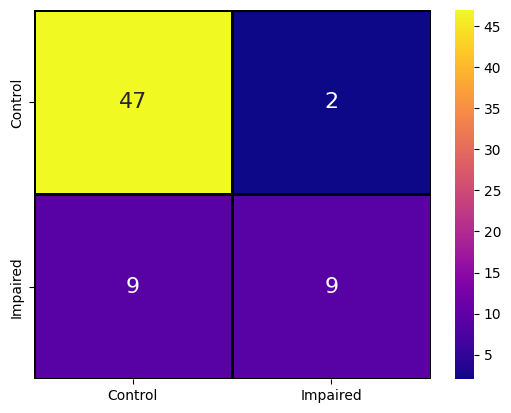

In [9]:
#Obtenção dos labels
labels = ["Control", "Impaired"]

#Obtenção da matrix de confusão
matriz_conf = confusion_matrix(target_teste, y_previsto_s_otim, labels=labels)
df_conf = pd.DataFrame(matriz_conf, labels, labels)

#Plotagem do gráfico
sns.heatmap(df_conf, cmap=cm.plasma, annot=True, annot_kws={"size": 16}, linewidths=1, linecolor='black');

savefig("ConfMat_RF_sem_otim.png")

Vemos que, para um modelo não otimizado, seu desempenhão não foi tão ruim. A taxa de acerto para a classe "Impaired" foi de 50%, o que não é ideal ou desejável, mas razoável para um modelo com hiperparâmetros padrão.

## Random Forest com otimização

A seguir iremos otimizar os seguintes hiperparâmetros da floresta:

- Número de árvores;
- Critério para split;
- Mínimo de exemplos por split;
- Mínimo de exemplos por folha;
- Número máximo de atributos avaliados por árvore.

Os ranges foram definidos conforme trabalho previamente realizado [1]. O único parâmetro cujo range foi alterado foi o de número máximo de atributos, antes sendo [0.0, 1]. Para esse parâmetro em específico alteramos o range pois um máximo de 0 não faria sentido e retornaria um modelo com árvores que não utilizavam nenhum atibuto para sua previsão.

In [10]:
def instancia_modelo(trial):
    """Cria uma instância do modelo.

    Argumentos:
      trial: objeto tipo Trial do optuna.

    Returno:
      Uma instância do modelo desejado.

    """
    
    parametros = {
        "n_estimators": trial.suggest_int("num_arvores", 100, 300),
        "criterion": trial.suggest_categorical("critério", ["gini", "entropy", "log_loss"]),
        "min_samples_split": trial.suggest_int("min_exemplos_split", 2, 15),
        "min_samples_leaf": trial.suggest_int("min_exemplos_folha", 1, 15),
        "max_features": trial.suggest_float("num_max_atributos", 0.2, 1),
        "n_jobs": -1,
        "bootstrap": True,
        "random_state": RANDOM_SEED,
    }

    modelo = RandomForestClassifier(**parametros)
    
    return modelo

Feito isso, iremos criar nossa função objetivo e estudo para armazenar os dados.

In [11]:
def funcao_objetivo(trial, features_treino, y, num_folds):
    """Função objetivo do optuna"""

    modelo = instancia_modelo(trial)

    metricas = cross_val_score(
        modelo,
        features_treino,
        y,
        scoring='f1',
        cv=num_folds,
    )

    return metricas.mean()

In [12]:
NOME_DO_ESTUDO = "random_forest_otim_fin"

objeto_de_estudo = create_study(
    direction="maximize",
    study_name=NOME_DO_ESTUDO,
    storage=f"sqlite:///{NOME_DO_ESTUDO}.db",
    load_if_exists=True,)

[I 2026-06-07 22:38:57,098] A new study created in RDB with name: random_forest_otim_fin


Vale notar abaixo que transformamos o target com um `LabelEncoder` para que o modelo pudesse receber os dados sem erros.

In [13]:
le=LabelEncoder()
y = le.fit_transform(target_treino.squeeze())

N_FOLDS = 10
N_TENTATIVAS = 100

def funcao_objetivo_parcial(trial):
    return funcao_objetivo(trial, features_treino, y, N_FOLDS)

Assim, basta rodar a otimização.

In [14]:
objeto_de_estudo.optimize(funcao_objetivo_parcial, n_trials=N_TENTATIVAS, n_jobs=5)

melhor_trial = objeto_de_estudo.best_trial
print(f"""O melhor trial foi o {melhor_trial.number} 
com os seguintes parâmetros: {melhor_trial.params}""")

[I 2026-06-07 22:39:25,967] Trial 0 finished with value: 0.5788228438228439 and parameters: {'num_arvores': 155, 'critério': 'entropy', 'min_exemplos_split': 6, 'min_exemplos_folha': 11, 'num_max_atributos': 0.20264294191780927}. Best is trial 0 with value: 0.5788228438228439.
[I 2026-06-07 22:39:26,443] Trial 3 finished with value: 0.5865922965922966 and parameters: {'num_arvores': 113, 'critério': 'gini', 'min_exemplos_split': 12, 'min_exemplos_folha': 7, 'num_max_atributos': 0.8276919570703505}. Best is trial 3 with value: 0.5865922965922966.
[I 2026-06-07 22:39:28,103] Trial 1 finished with value: 0.6101243201243202 and parameters: {'num_arvores': 238, 'critério': 'entropy', 'min_exemplos_split': 5, 'min_exemplos_folha': 6, 'num_max_atributos': 0.5653397065341919}. Best is trial 1 with value: 0.6101243201243202.
[I 2026-06-07 22:39:28,473] Trial 2 finished with value: 0.542077922077922 and parameters: {'num_arvores': 205, 'critério': 'log_loss', 'min_exemplos_split': 6, 'min_exempl

O melhor trial foi o 76 
com os seguintes parâmetros: {'num_arvores': 292, 'critério': 'log_loss', 'min_exemplos_split': 14, 'min_exemplos_folha': 2, 'num_max_atributos': 0.6095103348807561}


Dessa forma obtemos o melhor trial e podemos avaliar seu desempenho.

Abaixo obtemos todas as métricas possíveis para o problema, mas usaremos somente o F1-score.

In [17]:
modelo_otim = instancia_modelo(melhor_trial)
modelo_otim.fit(features_treino, target_treino)

y_verdadeiro = target_teste
y_previsto_otim = modelo_otim.predict(features_teste)

print(classification_report(y_verdadeiro, y_previsto_otim))

C:\Users\ana25003\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


              precision    recall  f1-score   support

     Control       0.90      0.94      0.92        49
    Impaired       0.81      0.72      0.76        18

    accuracy                           0.88        67
   macro avg       0.86      0.83      0.84        67
weighted avg       0.88      0.88      0.88        67



Tembém obteremos a matriz de confusão para compreender como esse modelo distribuiu os labels.

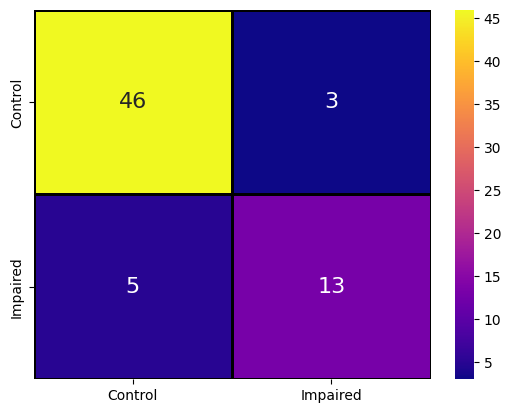

In [18]:
#Obtenção dos labels
labels = ["Control", "Impaired"]

#Obtenção da matrix de confusão
matriz_conf = confusion_matrix(y_verdadeiro, y_previsto_otim, labels=labels)
df_conf = pd.DataFrame(matriz_conf, labels, labels)

#Plotagem do gráfico
sns.heatmap(df_conf, cmap=cm.plasma, annot=True, annot_kws={"size": 16}, linewidths=1, linecolor='black');

savefig("ConfMat_RF_otim.png")

Podemos ver que o modelo obtido foi bastante razoável para esse problema de classificação, apresentando acerto absoluto de 59/67 ou 88% de acerto. Vale dizer que podemos apontá-lo como razoável especialmente por seus acertos na classificação de "Impaired".

## Resultados e conclusão

Podemos observar que para uma RF otimizada, o resultado é claramente melhor na classificação de "Impaired", embora seu desempenho para classificar "Control" tenha caído levemente.

Para análise comparativa dos resultados, retorne ao notebook `0 - A Rota da Neuromante - Análise do problema, discussão de resultados e conclusão`.